In [32]:
import pandas as pd

In [33]:
df = pd.read_excel('./cohort.xlsx')

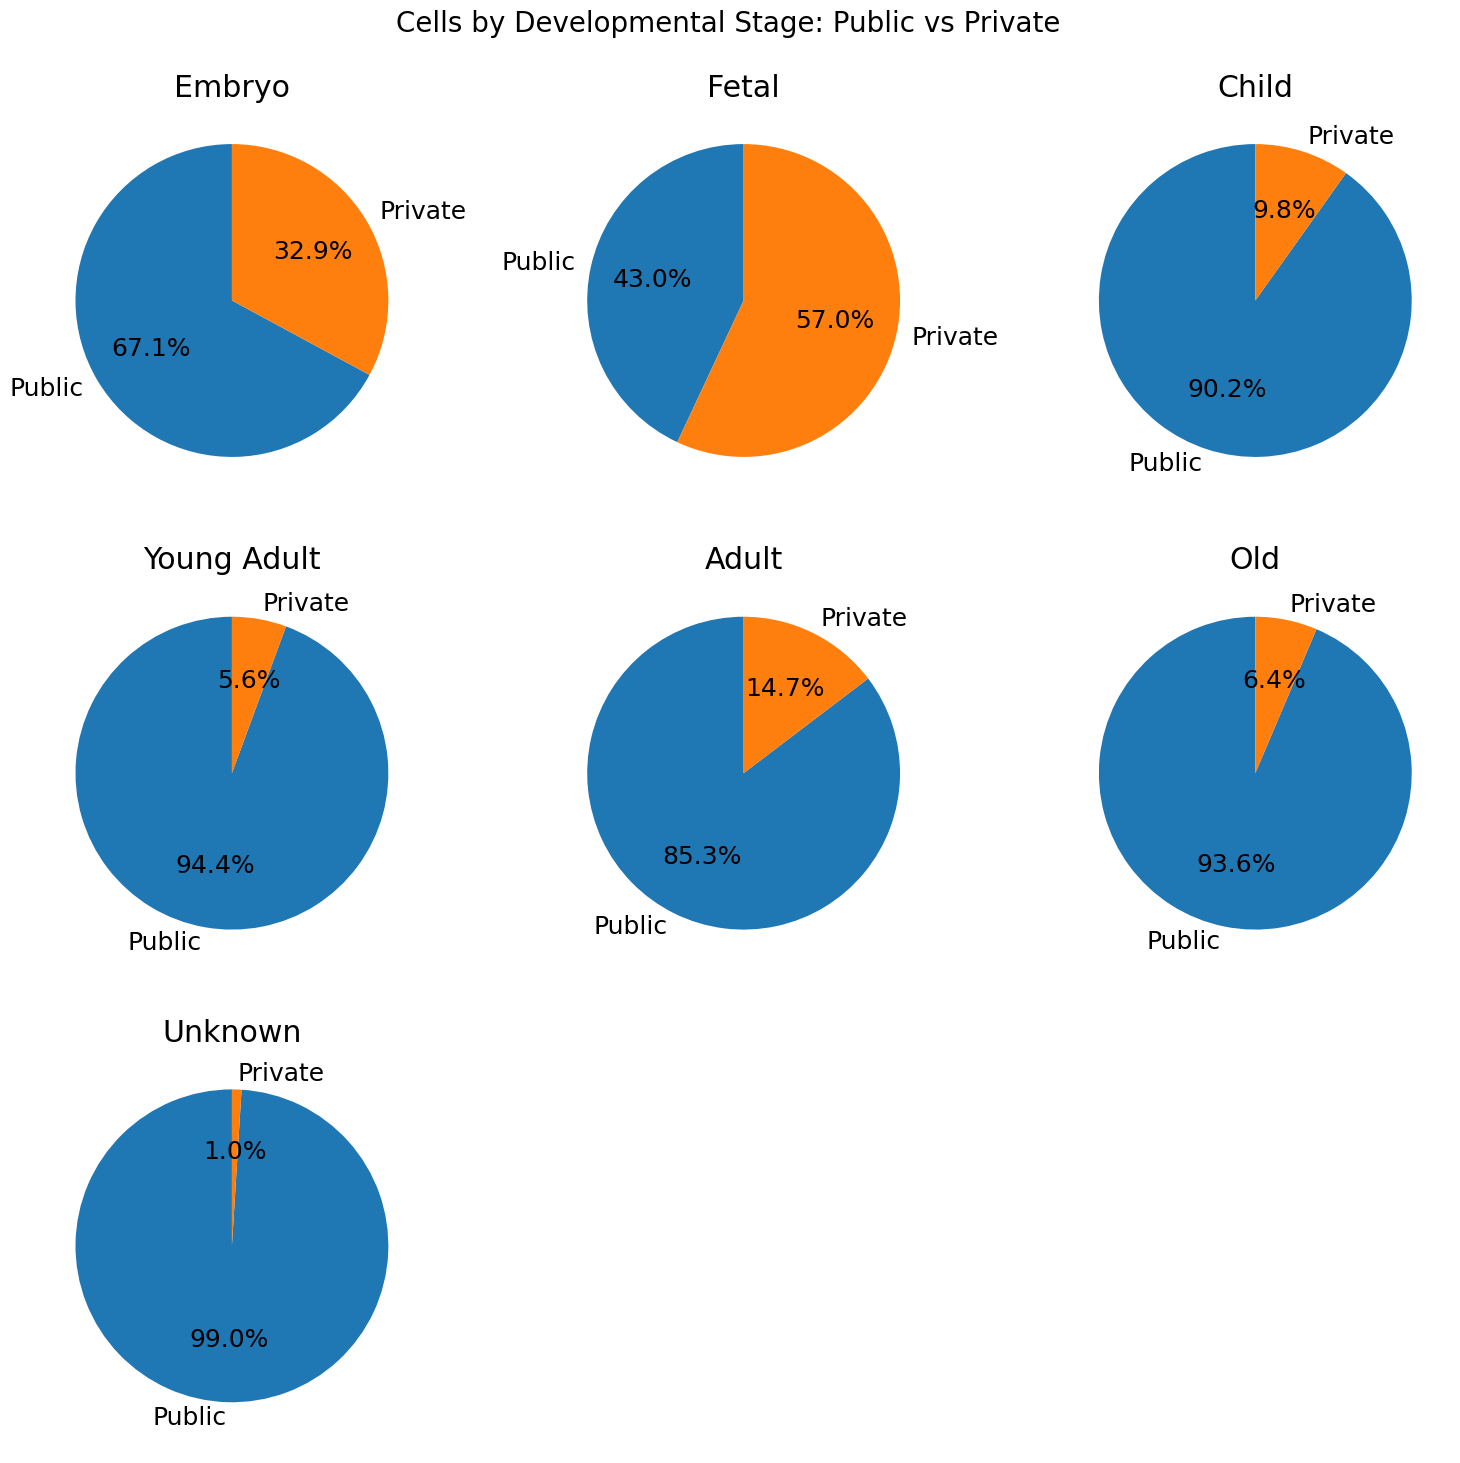

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
stage_cols = ["Embryo", "Fetal", "Child", "Young Adult", "Adult", "Old", "Unknown"]
status_col = "status"  # column with 'Public'/'Private'
# --- 1) Set plot style ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

# --- 3) Reshape & aggregate ---
# Melt into long format: one row per (row, stage)
stage_cols = ["Embryo", "Fetal", "Child", "Young Adult", "Adult", "Old", "Unknown"]
status_col = "status"

# --- 4) Reshape & aggregate ---
long = df.melt(id_vars=[status_col], value_vars=stage_cols,
               var_name="stage", value_name="cells")
long["cells"] = pd.to_numeric(long["cells"], errors="coerce").fillna(0).clip(lower=0)
by_stage_status = (long.groupby(["stage", status_col], as_index=False)["cells"].sum())

all_status = ["Public", "Private"]
def get_stage_slice(stage):
    s = by_stage_status[by_stage_status["stage"] == stage].set_index(status_col)
    return s.reindex(all_status, fill_value=0)["cells"]

# --- 5) Plot all stages ---
stages_with_cells = [st for st in stage_cols if get_stage_slice(st).sum() > 0]
cols, rows = 3, ceil(len(stages_with_cells)/3)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))

# Normalize axes array shape
if rows == 1 and cols == 1:
    axes = [[axes]]
elif rows == 1:
    axes = [axes]

for idx, stage in enumerate(stages_with_cells):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    counts = get_stage_slice(stage)
    total = counts.sum()
    if total == 0:
        ax.axis("off")
        continue
    nonzero_mask = counts > 0
    ax.pie(
        counts[nonzero_mask].values,
        labels=counts.index[nonzero_mask],
        autopct='%1.1f%%',
        startangle=90
    )
    ax.set_title(stage)

# Turn off unused subplots
for j in range(len(stages_with_cells), rows*cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

fig.suptitle("Cells by Developmental Stage: Public vs Private", fontsize=20)
plt.tight_layout()

# --- 6) Save figure ---
plt.savefig("dev_stage_public_private_pies.pdf", dpi=300, bbox_inches="tight")
plt.savefig("dev_stage_public_private_pies.png", dpi=300, bbox_inches="tight")
plt.savefig("dev_stage_public_private_pies.svg", bbox_inches="tight")
plt.show()

In [35]:
by_stage_status

,stage,status,cells
0,Adult,Private,1376122
1,Adult,Public,8012397
2,Child,Private,305649
3,Child,Public,2799203
4,Embryo,Private,1012694
5,Embryo,Public,2066294
6,Fetal,Private,1230033
7,Fetal,Public,929113
8,Old,Private,1139048
9,Old,Public,16673005


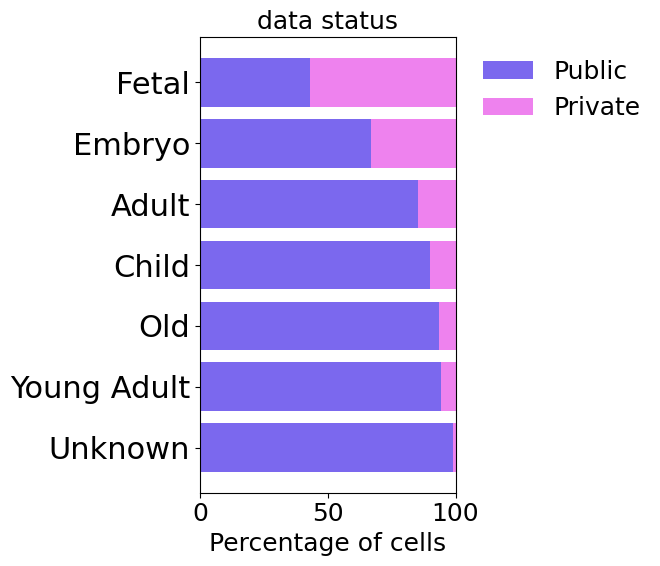

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Pivot to wide format ---
wide = (
    by_stage_status
    .pivot(index="stage", columns="status", values="cells")
    .fillna(0)
)

# --- Convert to percentages ---
pct = wide.div(wide.sum(axis=1), axis=0) * 100

# --- Order by percentage of Private (descending) ---
pct = pct.sort_values("Private", ascending=False)
pct = pct.iloc[::-1]   # <- makes top-to-bottom correct

# --- Plot: horizontal stacked bar chart (percentages) ---
fig, ax = plt.subplots(figsize=(7, max(6, 0.6 * len(pct))))

# Choose custom colors
public_color = "mediumslateblue"
private_color = "violet"

ax.barh(
    pct.index,
    pct["Public"],
    label="Public",
    color=public_color
)

ax.barh(
    pct.index,
    pct["Private"],
    left=pct["Public"],
    label="Private",
    color=private_color
)

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of cells")
ax.set_title("data status", fontsize=18)

ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.yticks(fontsize=22)

plt.tight_layout()

# --- Save ---
plt.savefig("dev_stage_public_private_stacked_pct_bar_horizontal.pdf", dpi=600, bbox_inches="tight")
plt.savefig("dev_stage_public_private_stacked_pct_bar_horizontal.png", dpi=600, bbox_inches="tight")
plt.savefig("dev_stage_public_private_stacked_pct_bar_horizontal.svg", dpi=600,bbox_inches="tight")
plt.show()


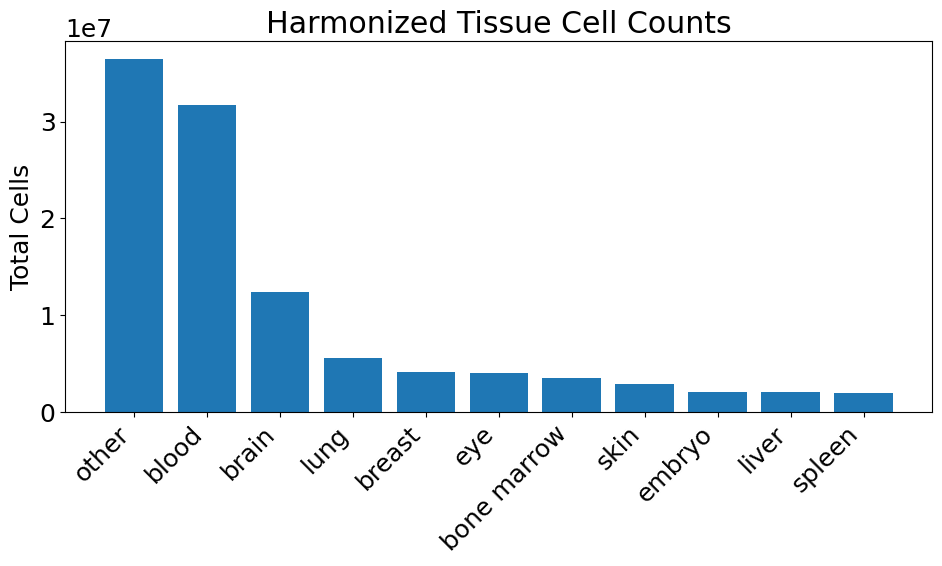

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Data you provided
data = {
    "blood": 31736248,
    "brain": 12396008,
    "lung": 5624790,
    "breast": 4139874,
    "eye": 4097010,
    "bone marrow": 3499098,
    "skin": 2876470,
    "embryo": 2057785,
    "liver": 2053312,
    "spleen": 2035135,
    "other": 36451954
}

# Convert to DataFrame
plot_df = pd.DataFrame(list(data.items()), columns=["Tissue", "Total Cells"])
plot_df = plot_df.sort_values("Total Cells", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.bar(plot_df["Tissue"], plot_df["Total Cells"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total Cells")
plt.title("Harmonized Tissue Cell Counts")
plt.tight_layout()
plt.show()


In [40]:
diseases = pd.read_excel('./diseases.xlsx')

In [41]:
unique_diseases = sorted(diseases["Value"].dropna().unique().tolist())
unique_diseases


['22q11 deletion (associated with schizophrenia)',
 'ALS',
 'Acute Coronary Syndrome',
 'Acute Liver Failure',
 'Acute Lymphocytic Leukemia (ALL)',
 'Acute Myeloid Leukemia',
 'Acute Myeloid Leukemia (AML)',
 'Acute Respiratory Distress Syndrome (ARDS) from COVID-19',
 'Acute lymphocytic leukemia (ALL)',
 'Adult-onset leukoencephalopathy with axonal spheroids and pigmented glia (ALSP)',
 'Allergic conjunctivitis',
 "Alzheimer's disease",
 "Alzheimer's disease (AD)",
 'Angiolymphoid Hyperplasia',
 'Atherosclerosis',
 'Autism-associated SHANK3 deficiency',
 'Benign Prostatic Hyperplasia (BPH)',
 'Blastic Plasmacytoid Dendritic Cell Neoplasm (BPDCN)',
 "Bowen's disease",
 'Breast cancer',
 'CD3-CD28-stimulated',
 'CMML',
 'COPD',
 'COVID-19',
 'COVID-19, Reconvalescence',
 'COVID-19, severe/critical Delta variant',
 'COVID-19, severe/critical delta',
 'Chronic Hepatitis B',
 'Chronic Myelogenous Leukemia (CML)',
 'Chronic Myelomonocytic Leukemia (CMML)',
 'Chronic Thromboembolic Pulmonary

In [42]:
category_rules = {
    "Healthy / Control": [
        "healthy", "control", "normal", "unaffected", "nondiabetic"
    ],

    "Infectious Disease": [
        "covid", "sars", "influenza", "hiv", "malaria", "ebola",
        "hepatitis", "pneumonia", "mrsa", "mssa"
    ],

    "Cancer / Hematologic": [
        "leukemia", "lymphoma", "myeloma", "mds", "cmml",
        "myelofibrosis", "bpdc", "clonal hematopoiesis"
    ],

    "Cancer / Neoplasm (Solid)": [
        "cancer", "carcinoma", "glioma", "glioblastoma",
        "adenocarcinoma", "sarcoma", "melanoma",
        "medulloblastoma", "neoplasm", "tumor", "pitnet"
    ],

    "Autoimmune / Inflammatory": [
        "crohn", "ulcerative colitis", "multiple sclerosis",
        "rheumatoid", "lupus", "sle", "psoriasis",
        "dermatitis", "vasculitis", "vitiligo",
        "hidradenitis", "scleroderma", "vexas"
    ],

    "Cardiovascular Disease": [
        "heart", "cardiac", "atherosclerosis", "myocardial",
        "coronary", "hypertension", "atrial fibrillation",
        "aneurysm"
    ],

    "Neurological / Neurodegenerative": [
        "alzheimer", "parkinson", "huntington",
        "dementia", "epilepsy", "ataxia",
        "neurodegenerative", "ftd"
    ],

    "Genetic / Developmental Disorder": [
        "trisomy", "down", "22q11", "kabuki",
        "neurofibromatosis", "lissencephaly",
        "hirschsprung", "sickle cell"
    ],

    "Metabolic / Endocrine": [
        "diabetes", "obesity", "pcos", "nash"
    ],

    "Respiratory Disease": [
        "copd", "pulmonary", "ipf", "ards",
        "sleep apnea", "respiratory"
    ],

    "Gastrointestinal / Liver Disease": [
        "liver", "hepatic", "cirrhosis", "colitis",
        "gastric", "esophageal", "pancreatic",
        "ibd", "gastro"
    ],

    "Dermatological Disease": [
        "skin", "acne", "alopecia", "lichen",
        "keloid", "psoriasis", "dermat"
    ],

    "Musculoskeletal Disease": [
        "arthritis", "osteoarthritis", "skeletal", "spinal"
    ],

    "Renal / Urogenital Disease": [
        "kidney", "renal", "ureter", "bladder"
    ],

    "Reproductive Disease": [
        "ovarian", "uterus", "prostate", "azoospermia"
    ],

    "Immune / Hematologic (Non-cancer)": [
        "anemia", "cytopenia", "immune disorder",
        "igg4", "aplastic"
    ],

    "Injury / Fibrosis / Wound": [
        "fibrosis", "injury", "scarring", "ulcer"
    ],

    "Uncertain / Metadata / Other": [
        "unsure", "not specified", "not explicitly",
        "other", "none", "tp53", "adrenal gland",
        "brain", "aorta", "ear", "eye", "mouth",
        "organ"
    ]
}


In [43]:
def assign_category(disease):
    d = disease.lower()
    for category, keywords in category_rules.items():
        if any(k in d for k in keywords):
            return category
    return "Uncertain / Metadata / Other"


In [44]:
diseases["Category"] = diseases["Value"].apply(assign_category)

In [45]:
category_totals = (
    diseases
    .groupby("Category", as_index=False)["Total Cells"]
    .sum()
    .sort_values("Total Cells", ascending=False)
)

category_totals


,Category,Total Cells
17,Uncertain / Metadata / Other,37469825
7,Healthy / Control,29116860
2,Cancer / Neoplasm (Solid),12402725
9,Infectious Disease,6484903
0,Autoimmune / Inflammatory,4192325
1,Cancer / Hematologic,3349497
13,Neurological / Neurodegenerative,3082024
3,Cardiovascular Disease,2292946
8,Immune / Hematologic (Non-cancer),1459844
6,Genetic / Developmental Disorder,1191616


In [46]:
category_totals.to_csv('./broad_disease.csv')

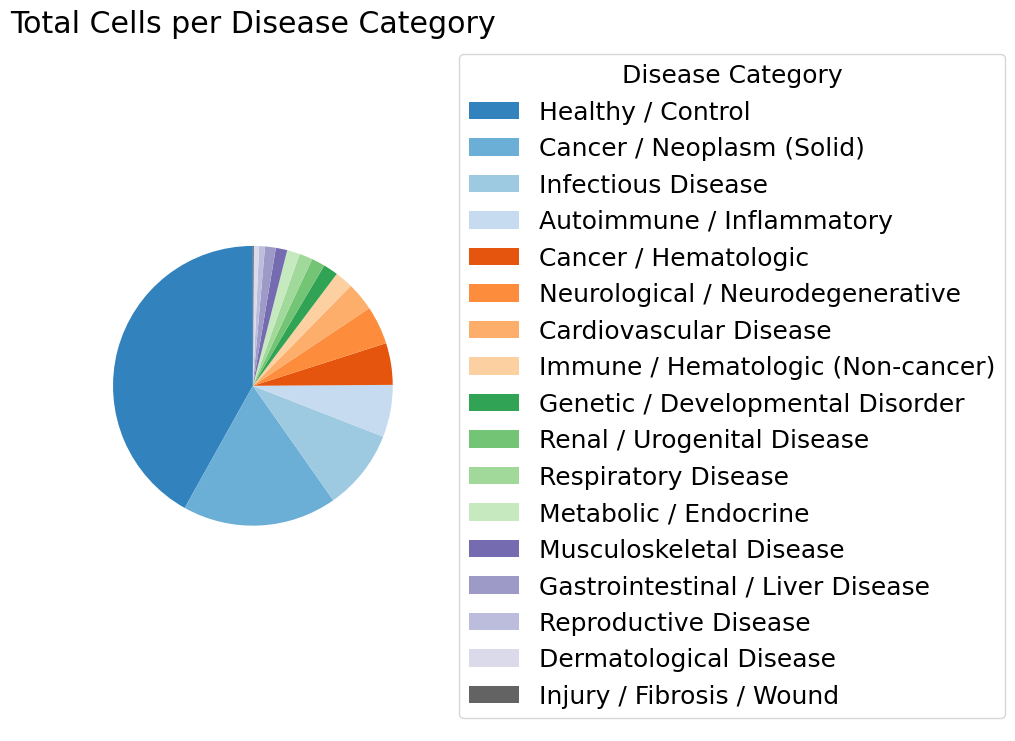

In [50]:
import matplotlib.pyplot as plt

# Exclude Uncertain / Metadata / Other
pie_df = category_totals[
    category_totals["Category"] != "Uncertain / Metadata / Other"
]

# Get tab20b palette
colors = plt.cm.tab20c.colors

plt.figure(figsize=(10, 8))

plt.pie(
    pie_df["Total Cells"],
    startangle=90,
    colors=colors[:len(pie_df)]
)

plt.title("Total Cells per Disease Category")
plt.axis("equal")

plt.legend(
    pie_df["Category"],
    title="Disease Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.savefig('disease_counts_piechart.svg',dpi=600)
plt.show()


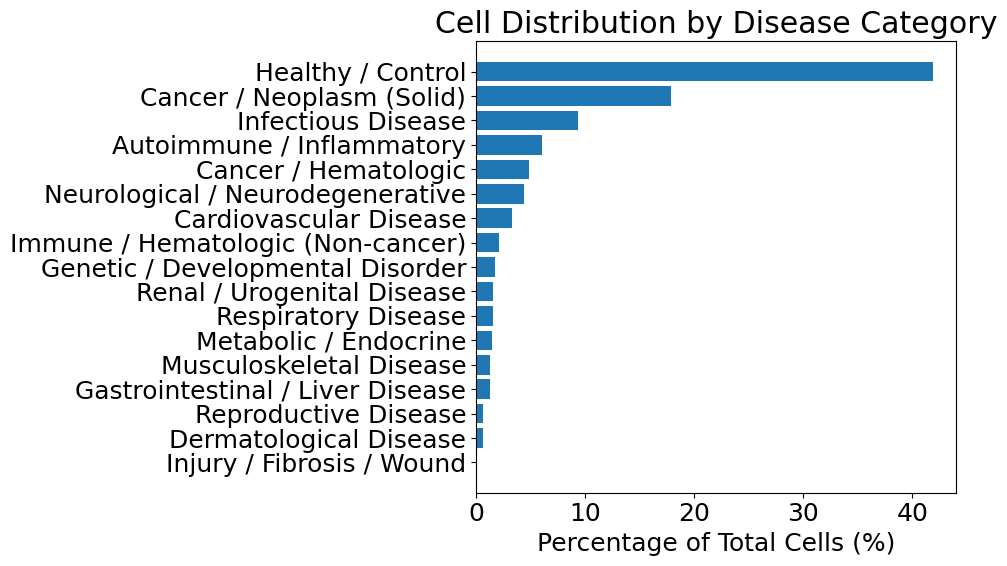

In [51]:
import matplotlib.pyplot as plt

# Exclude unwanted category
bar_df = category_totals[
    category_totals["Category"] != "Uncertain / Metadata / Other"
].copy()

# Compute percentages
total_cells = bar_df["Total Cells"].sum()
bar_df["Percentage"] = 100 * bar_df["Total Cells"] / total_cells

# Sort descending
bar_df = bar_df.sort_values("Percentage", ascending=False)
plt.figure(figsize=(10, 6))

plt.barh(
    bar_df["Category"],
    bar_df["Percentage"]
)

plt.xlabel("Percentage of Total Cells (%)")
plt.title("Cell Distribution by Disease Category")

# Put largest at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('disease_counts_bar.svg',dpi=600)
plt.show()
